In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [3]:
def pmf_v(p, q, v):
    """Ймовірність суми v при заданих p та q [cite: 11]"""
    if v == 3:
        return p * q
    elif v == 4:
        return p * (1 - q) + (1 - p) * q
    elif v == 5:
        return (1 - p) * (1 - q)
    else:
        return 0

In [4]:
def log_likelihood(p, q, counts):
    eps = 1e-10
    prob3 = pmf_v(p, q, 3) + eps
    prob4 = pmf_v(p, q, 4) + eps
    prob5 = pmf_v(p, q, 5) + eps
    
    ll = (counts[0] * np.log(prob3) + 
          counts[1] * np.log(prob4) + 
          counts[2] * np.log(prob5))
    return ll

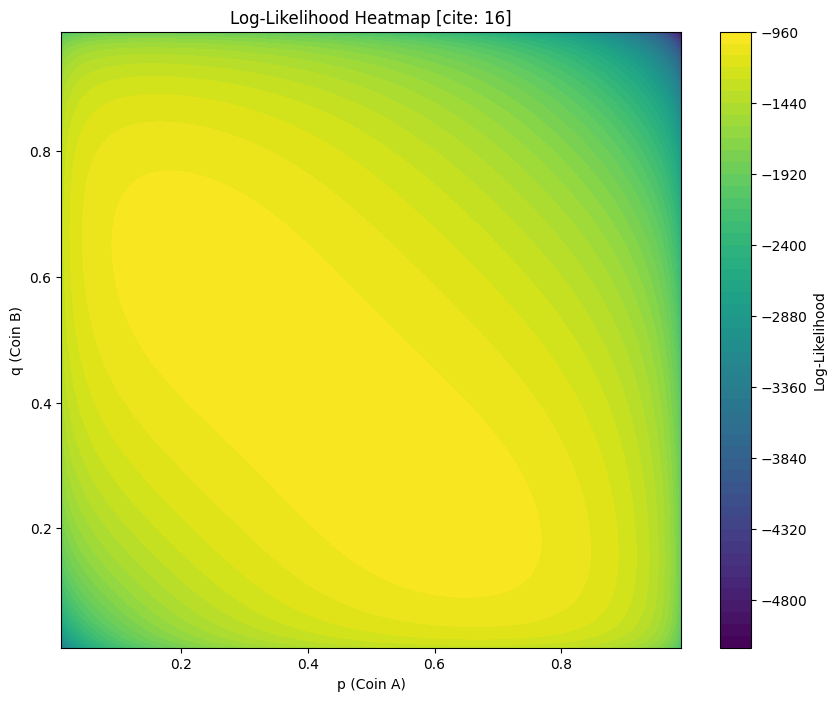

In [5]:
observed_counts = [148, 529, 323]

# Візуалізація
p_range = np.linspace(0.01, 0.99, 100)
q_range = np.linspace(0.01, 0.99, 100)
P, Q = np.meshgrid(p_range, q_range)

Z = np.array([[log_likelihood(p, q, observed_counts) for p in p_range] for q in q_range])

plt.figure(figsize=(10, 8))
cp = plt.contourf(P, Q, Z, levels=50, cmap='viridis')
plt.colorbar(cp, label='Log-Likelihood')
plt.xlabel('p (Coin A)')
plt.ylabel('q (Coin B)')
plt.title('Log-Likelihood Heatmap [cite: 16]')
plt.show()

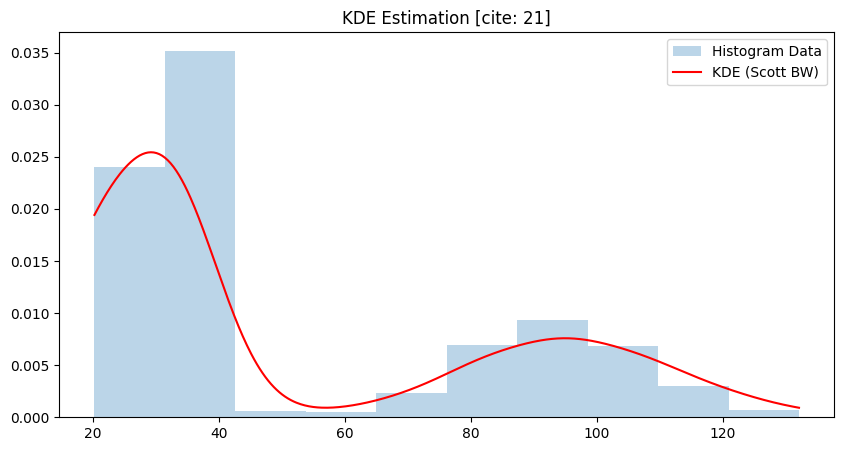

In [6]:
values = np.array([20.3, 32.7, 45.2, 57.6, 70, 82.4, 94.9, 107.3, 119.7, 132.1])
counts = np.array([402, 590, 10, 9, 39, 116, 157, 115, 50, 12])

data_sample = np.repeat(values, counts)

kde = gaussian_kde(data_sample, bw_method='scott') 
x_eval = np.linspace(min(values), max(values), 500)

plt.figure(figsize=(10, 5))
plt.hist(data_sample, bins=10, density=True, alpha=0.3, label='Histogram Data')
plt.plot(x_eval, kde(x_eval), 'r', label='KDE (Scott BW)')
plt.title('KDE Estimation [cite: 21]')
plt.legend()
plt.show()